# Model Development and Evaluation
## Wisconsin Diagnostic Breast Cancer 

---

## Motivating Problem
#### Can we develop a machine learning model to assist radiologists in distinguishing malignant from benign breast masses using cell morphology features, in order to reduce unnecessary biopsies while maintaining high cancer detection rates?

## Notebook Structure
This notebook trains and evaluates several machine learning models to classify breast tumors as benign or malignant using the [Wisconsin Diagnostic Breast Cancer dataset](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic), which contains features describing 10 core characteristics of cell nuclei present in the digitized images of fine needle aspirates.  

**Models Evaluated**:
- Logistic Regression (No regularization)
- Logistic Regression (L1 regularization)
- Logistic Regression (L2 regularization)
- Random Forest
- Support Vector Machine

**Evaluation Metrics**: accuracy, sensitivity, specificity, AUC-ROC, and confusion matrices.

<!-- ### Notebook structure
- Data preparation (load data, split)
- Baseline Model: Logistic Regression (train + evaluate)
- Logistic Regression (L1 Regularization) (train + evaluate)
- Random Forest (train + evaluate)
- SVM
- Model comparison (compare_models)
- Hyperparameter tuning (NEW)
- Evaluate tuned models
- Confusion Matrices
- ROC curve comparison
- Feature Importance (RF) (interpretability) (medically relevant predictors)
- Logistic Regression Coefficient Plot (which features increase malignant risk)
    - positive coefficient = higher malignancy risk
    - negative coefficient = benign tendency
- Discussion 
- Key Findings  -->

### Imports
_The src/ folder contains python (.py) scripts needed for running the .ipynb files contained in the notebooks/ (this) folder. The functions in each script help with a certain aspect of the project. At the top of each .ipynb in the notebooks/ folder you will find a code block that sets up access to the src/ folder and its functions. If you remove this code block you will not be able to properly run the notebook._

In [1]:
import sys
from pathlib import Path

# Get repo root (one level above notebooks/)
repo_root = Path().resolve().parent
src_path = repo_root / "src"

# Add src folder to Python path
if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

# import modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, precision_recall_curve

# import custom modules (located in src/)
import visualization as vis 
from preprocessing import load_raw_data, get_Xy, split_data
from pipelines import logistic_pipeline, rf_pipeline, svm_pipeline
from train import train_model
from tune import get_param_grid, tune_model, extract_feature_importance
from evaluate import evaluate_model, cross_validate_model
from compare import compare_models

# Suppress sklearn warnings (clean output)
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="sklearn")
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

# settings
sns.set_style(style="white")
print("> Loaded required libraries")

> Loaded required libraries


In [2]:
# hard-coded variables or flags
cols = {"malignant": "darkblue", "benign": "#04b2d1"} # target
# cols = {"malignant": "#1f77b4", "benign": "#ff7f0e"} # target
measures = ["mean", "error", "worst"]
measures_cols = {"mean": "#3498DB", "error": "#F39C12", "worst": "#E74C3C"} # measures

### Data & Model Preparation
The raw dataset is loaded and cleaned using a helper function. Cleaning steps include standardizing column names and encoding the target variable (malignant = 1, benign = 0). The data are separated into features (X) and target (y) before being split into training and test sets. 

As discussed in the [exploratory data analysis (01_eda.ipynb)](https://github.com/sarahcreighton/breast-cancer-classifier/blob/main/notebooks/01_eda.ipynb), the dataset contains more benign tumors (63%) than malignant tumors (37%), and although the class imbalance is moderate and unlikely to severely bias model training, we stratified sampling to preserve class balance. All analyses use an 80/20 train-test split, and stratified sampling unless otherwise specified. 

Our analyses make use of scikit-learn pipelines to ensure proper scaling (standardization) for the logistic regression and SVM models, and eliminating the risk of data leakage. Scaling is particularly important for this dataset due to the high degree of multicollinearity present.  

In [3]:
data_path = "../data/raw/wdbc.data"
df = load_raw_data(data_path)
X, y = get_Xy(df) 
X_train, X_test, y_train, y_test = split_data(X, y)

print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])

Training samples: 455
Test samples: 114


### PCA Visualization of Tumor Types
We used Principle Components Analysis (PCA) to reduce the high-dimensional feature space of our dataset to $n$ lower-dimensions to visualize how benign and malignant tumors separate. In the plot below, the malignant tumors cluster separately from the benign tumors, suggesting models will be able to classify them well. The first two principle components explain roughly 63% of the variance.

Projection onto the first two principle components reveals a strong separation between malignant and benign samples, indicating that the underlying feature space contains structure suitible for classification.

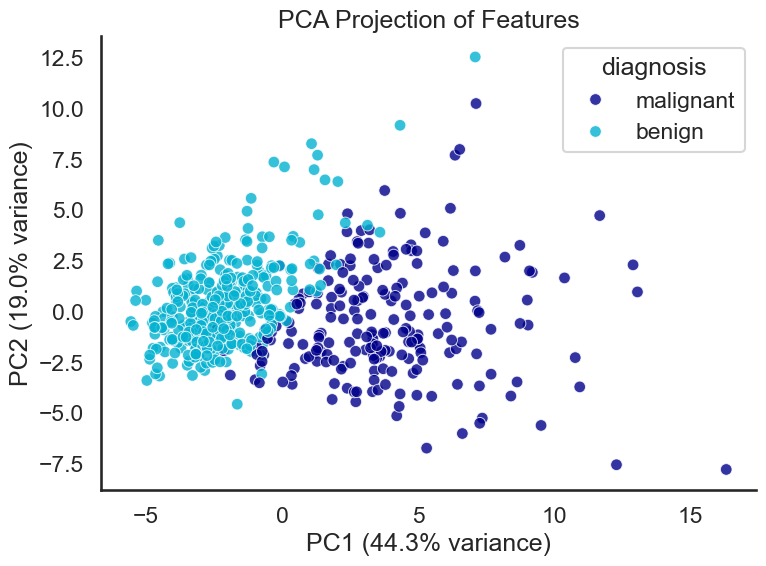

In [4]:
vis.plot_pca(df, palette=cols)

## Logistic Regression Models
Logistic regression models with both L1 and L2 regularization were evaluated. L1 regularization was implemented using the `liblinear` solver, while L2 used the default `lbfgs` solver, consistent with scikit-learn recommendations.

### 1. Baseline Logistic Regression (No Regularization)

In [6]:
# set up pipeline
logistic_pipe = logistic_pipeline(penalty=None, C=1.0)

# train model
trained_logistic = train_model(logistic_pipe, X_train, y_train)

# evaluate model 
metrics, cm = evaluate_model(
    trained_logistic, 
    X_test, y_test, 
    model_name="Logistic (Baseline)")

metrics

,Accuracy,Sensitivity,Specificity,ROC-AUC,Precision,F1-Score
Model,,,,,,
Logistic (Baseline),0.9386,0.881,0.9722,0.9669,0.9487,0.9136


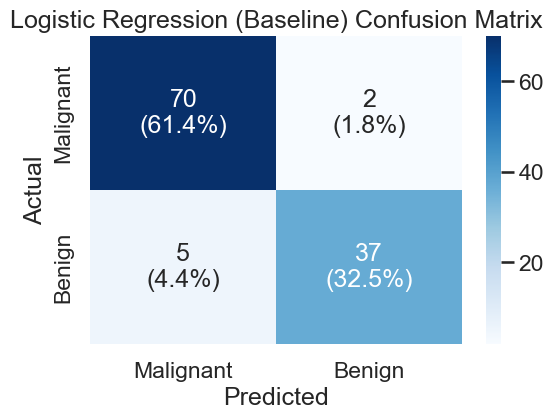

In [ ]:
# probably best to plot all three LR together in one figure
cm_sum = cm.sum()
cm_pct = cm/cm_sum

labels = np.array([
    [
        f"{cm[i,j]}\n({cm_pct[i,j]:.1%})"
        for j in range(cm.shape[1])
    ]
    for i in range(cm.shape[0])
])

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=labels,
    fmt="",
    cmap="Blues",
    xticklabels=["Malignant", "Benign"],
    yticklabels=["Malignant", "Benign"]
)

plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.title("Logistic Regression (Baseline) Confusion Matrix")

plt.show()

### Compare Multiple Models
Although logistic regression in sklearn uses an L2 penalty as the default, we will explore how our results change with and without regularization. 

We test 3 different baseline classifier models: logistic regression, random forest, and support vector.

In [ ]:
# compare 3 baseline models (sklearn default settings)
models = {
    "Logistic (L2)": logistic_pipeline(),
    "Random Forest": rf_pipeline(),
    "Support Vector": svm_pipeline()
}

lr_models = {
    "Logistic (No Reg)": logistic_pipeline(penalty=None),
    "Logistic (L1 Reg)": logistic_pipeline(penalty="l1"),
    "Logistic (L2 Reg)": logistic_pipeline(penalty="l2")
}

results, cms, trained_models = compare_models(
    models, 
    X_train, 
    y_train, 
    X_test, 
    y_test
)

results = results.sort_values(by="ROC-AUC",ascending=False).style.highlight_max(color="seagreen")
# results = results.sort_values(by="ROC-AUC",ascending=False).round(3).style.highlight_max(color="seagreen")
results

,Accuracy,Sensitivity,Specificity,ROC-AUC,Precision,F1-Score
Model,,,,,,
Logistic (L2),0.964900,0.928600,0.986100,0.996000,0.975000,0.951200
Support Vector,0.973700,0.928600,1.000000,0.994700,1.000000,0.963000
Random Forest,0.964900,0.904800,1.000000,0.994200,1.000000,0.950000


### Visualize Confusion Matrices

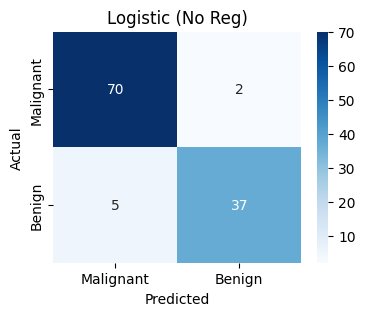

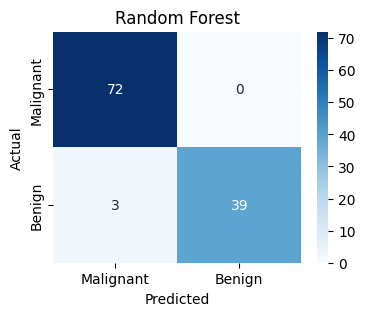

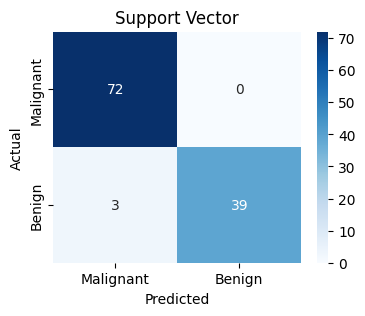

In [ ]:
for name, cm in cms.items():

    plt.figure(figsize=(4,3))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Malignant", "Benign"],
        yticklabels=["Malignant", "Benign"]
    )

    plt.title(f"{name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

# cm = results_df.loc[results_df.model=="Log_L2", "confusion_matrix"].values[0]
# sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
# plt.title("Log_L2 Confusion Matrix")
# plt.show()

### ROC Curve Comparison

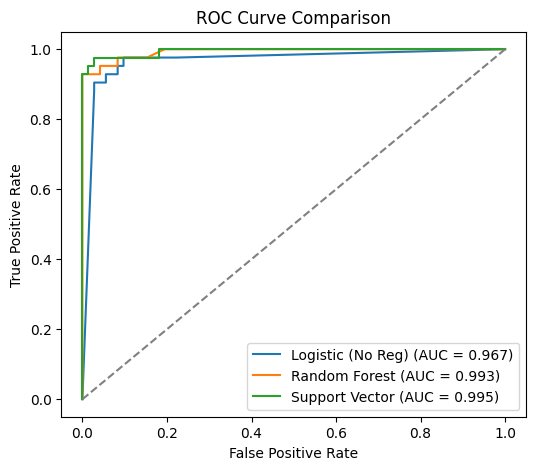

In [39]:
plt.figure(figsize=(6,5))

for name, model in trained_models.items():

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:,1]

        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_auc = auc(fpr, tpr)

        plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0,1],[0,1], linestyle="--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

### Precision-Recall Curves
Precision-Recall curves are particularly informative for medical classification tasks because they highlight the tradeoff between detecting malignant tumors (recall) and avoiding false alarms (precision).

Recall: how many malignant tumors were detected (hits)
Precision: how many predicted malignant tumors were correct? (hit rate)

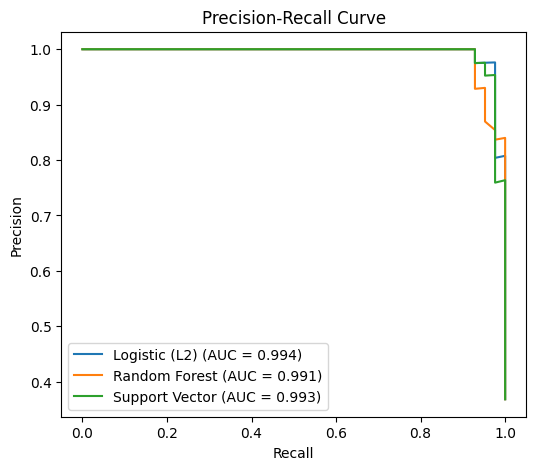

In [ ]:
plt.figure(figsize=(6,5))

for name, model in trained_models.items():

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:,1]

        precision, recall, _ = precision_recall_curve(y_test, y_proba)

        pr_auc = auc(recall, precision)

        plt.plot(
            recall, 
            precision, 
            label=f"{name} (AUC = {pr_auc:.3f})"
        )

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curve")
plt.legend()

plt.show()

#### Observations:
x achieves the highest precision-recall AUC, indicating better performance when prioritizing detection of malignant tumors while minimizing false positives.

### Feature Importance (Random Forest)

/var/folders/mq/rnygjqw54g58vnr3thv5xq6r0000gn/T/ipykernel_846/849763480.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


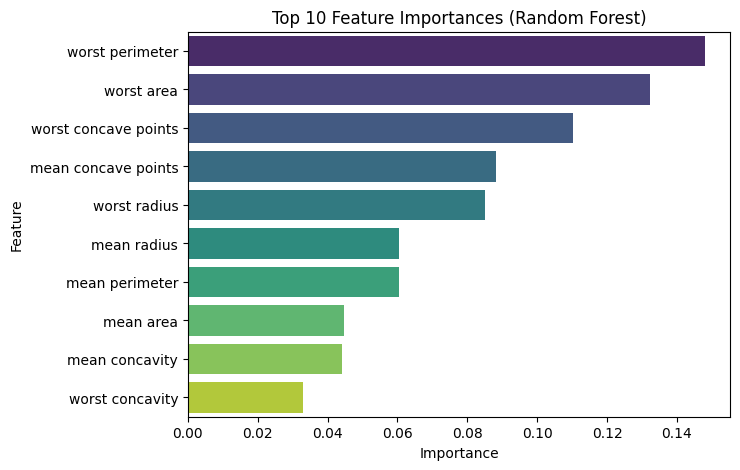

In [48]:
rf_model = trained_models["Random Forest"]
importances = rf_model.named_steps["model"].feature_importances_
features = X_train.columns

importance_df = (
    pd.DataFrame({
        "feature": features,
        "importance": importances
    })
    .sort_values("importance", ascending=False)
    .head(10)
)

plt.figure(figsize=(7,5))

sns.barplot(
    data = importance_df,
    x = "importance",
    y = "feature",
    palette = "viridis"
)

plt.title("Top 10 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

### Logistic Regression Coefficients

/var/folders/mq/rnygjqw54g58vnr3thv5xq6r0000gn/T/ipykernel_846/724059967.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


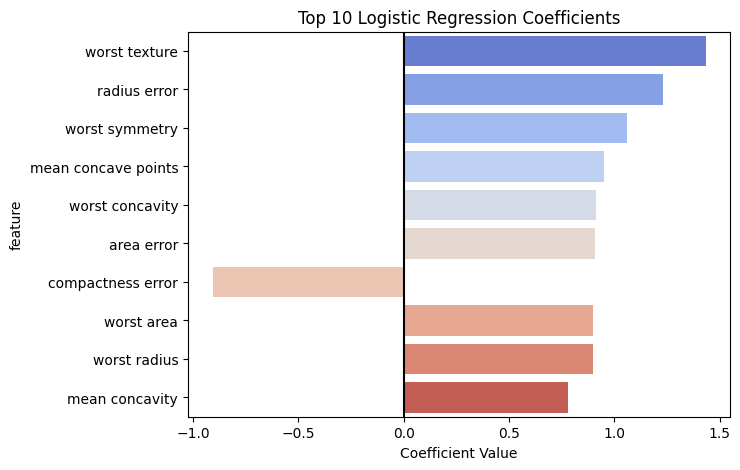

In [49]:
log_model = trained_models["Logistic (L2)"]
coefs = log_model.named_steps["model"].coef_[0]

coef_df = (
    pd.DataFrame({
        "feature": X_train.columns,
        "coefficient": coefs
    })
    .sort_values("coefficient", key=abs, ascending=False)
    .head(10)
)

plt.figure(figsize=(7,5))

sns.barplot(
    data = coef_df, 
    x="coefficient", 
    y="feature",
    palette="coolwarm"
)

plt.axvline(0, color="black")

plt.title("Top 10 Logistic Regression Coefficients")
plt.xlabel("Coefficient Value")

plt.show()

### Threshold Comparisons

In [ ]:
thresholds = [0.5, 0.4, 0.3, 0.2]

### Cross Validation

In [43]:
scoring = "roc_auc"
for name, model in trained_models.items():
    cv_metrics = cross_validate_model(model, X_train, y_train, cv=5, scoring=scoring)
    print(f"{name}\tCV {scoring}: {cv_metrics['cv_mean']:.3f} ± {cv_metrics['cv_std']:.3f}")

Logistic (No Reg)	CV roc_auc: 0.995 ± 0.005
Random Forest	CV roc_auc: 0.989 ± 0.013
Support Vector	CV roc_auc: 0.994 ± 0.005


### Discussion

<!-- EXAMPLE: Logistic regression achieved strong performance, with high sensitivity and specificity.

L1 regularization slightly reduced performance but provided a more sparse and interpretable model.

Random Forest achieved the highest ROC-AUC and precision-recall performance, but at the cost of interpretability(?) 

Features related to tumor perimeter, concavity, and radius were the strongest predictors of malignancy

Visualization using PCA shows partial separability between benign and malignant tumors in feature space-->

In [ ]:
# # SAMPLE WORKFLOW

# # 1. Imports
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

# from src.preprocessing import prepare_model_data
# from src.pipelines import logistic_pipeline, rf_pipeline, svm_pipeline
# from src.compare import compare_models
# from src.evaluate import cross_validate_model

# # 2. Load and prepare data
# data = prepare_model_data("data/raw/wdbc.data")

# print("Train shape:", data.X_train.shape)
# print("Test shape:", data.X_test.shape)

# # 3. Define pipelines/models
# models = {
#     "Log_L2": logistic_pipeline(penalty="l2", C=1.0),
#     "Log_L1": logistic_pipeline(penalty="l1", C=1.0),
#     "RF": rf_pipeline(n_estimators=200, max_depth=None)
# }

# # Optional: SVM for non-linear benchmark
# # models["SVM"] = svm_pipeline(C=1.0, kernel="rbf")

# # 4. Compare models using hold-out test set
# results_df, trained_models = compare_models(
#     models,
#     data.X_train, data.y_train,
#     data.X_test, data.y_test,
#     return_models=True
# )

# # Sort by ROC-AUC for readability
# results_df = results_df.sort_values(by="roc_auc", ascending=False)
# results_df

# # 5. Optional: cross-validation for stability
# cv_summary = {}
# for name, model in trained_models.items():
#     cv_metrics = cross_validate_model(model, data.X_train, data.y_train, cv=5)
#     cv_summary[name] = cv_metrics
#     print(f"{name} CV ROC-AUC: {cv_metrics['cv_mean']:.3f} ± {cv_metrics['cv_std']:.3f}")

# # 6. Plot confusion matrices
# for name, metrics in zip(results_df.model, results_df.confusion_matrix):
#     cm = metrics  # already a labeled DataFrame
#     plt.figure(figsize=(4,3))
#     sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
#     plt.title(f"{name} Confusion Matrix")
#     plt.show()

# # 7. Optional: ROC curves if predict_proba available
# from sklearn.metrics import roc_curve, auc

# plt.figure(figsize=(6,5))

# for name, model in trained_models.items():
#     if hasattr(model, "predict_proba"):
#         y_proba = model.predict_proba(data.X_test)[:,1]
#         fpr, tpr, _ = roc_curve(data.y_test, y_proba)
#         roc_auc = auc(fpr, tpr)
#         plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

# plt.plot([0,1], [0,1], "k--", alpha=0.5)
# plt.xlabel("False Positive Rate")
# plt.ylabel("True Positive Rate")
# plt.title("ROC Curves")
# plt.legend()
# plt.show()


# ###### How to display CM plots with numbers
# # Option 1: access a specific model
# # Get the confusion matrix for Log_L2
# cm = results_df.loc[results_df.model=="Log_L2", "confusion_matrix"].values[0]
# display(cm)  # this will render the numbers in notebook

# # Option 2. Iterate through all models
# for name, cm in zip(results_df.model, results_df.confusion_matrix):
#     print(f"Confusion Matrix for {name}:\n")
#     display(cm)

# # Option 3: Heatmap plot directly
# for name, cm in zip(results_df.model, results_df.confusion_matrix):
#     plt.figure(figsize=(4,3))
#     sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
#     plt.title(f"{name} Confusion Matrix")
#     plt.show()

# ###### Inspect coefficients
# # Feature importance (coefficients)
# coef_df = pd.DataFrame({
#     "feature": X.columns,
#     "coefficient": logreg.coef_[0]
# }).sort_values(by="coefficient", key=abs, ascending=False)

# coef_df.head(10)

---

Author: SE Creighton \
_Last Updated: 2026-03-06_